In [14]:
import numpy as np # type: ignore
import cv2 # type: ignore
import matplotlib.pyplot as plt # type: ignore

Funciones para graficar imagenes una al lado de otra

In [15]:
def show_two_images(image1,image2, title1 = "", title2 ="", size =(8,5)):    
    # Crear una figura con dos subplots (una fila, dos columnas)
    fig, axes = plt.subplots(1, 2, figsize= size)  # Ajusta el tamaño de la figura según sea necesario

    # Mostrar la primera imagen en el primer subplot
    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')  # Opcional: para ocultar los ejes

    # Mostrar la segunda imagen en el segundo subplot
    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')  # Opcional: para ocultar los ejes

    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()



def show_three_images(image1,image2,image3, title1 = "", title2 ="", title3 ="", size = (8,5)):    
    # Crear una figura con dos subplots (una fila, dos columnas)
    fig, axes = plt.subplots(1, 3, figsize =size)  # Ajusta el tamaño de la figura según sea necesario

    # Mostrar la primera imagen en el primer subplot
    axes[0].imshow(image1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')  # Opcional: para ocultar los ejes

    # Mostrar la segunda imagen en el segundo subplot
    axes[1].imshow(image2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')  # Opcional: para ocultar los ejes

    # Mostrar la segunda imagen en el segundo subplot
    axes[2].imshow(image3, cmap='gray')
    axes[2].set_title(title3)
    axes[2].axis('off')  # Opcional: para ocultar los ejes
    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()

Cargo las imagenes y pruebo llevarlas a todas a una misma resolución

In [16]:
#Imagenes de 2500 pixeles (50x50)
pandaOriginal = cv2.imread("panda.bmp", cv2.IMREAD_GRAYSCALE)
vOriginal = cv2.imread("v.bmp", cv2.IMREAD_GRAYSCALE)
perroOriginal = cv2.imread("perro.bmp", cv2.IMREAD_GRAYSCALE)

#Imagenes de 2925 pixeles (65x45)
quijoteOriginal = cv2.imread("quijote.bmp", cv2.IMREAD_GRAYSCALE)
palomaOriginal = cv2.imread("paloma.bmp", cv2.IMREAD_GRAYSCALE)
toreroOriginal = cv2.imread("torero.bmp", cv2.IMREAD_GRAYSCALE)


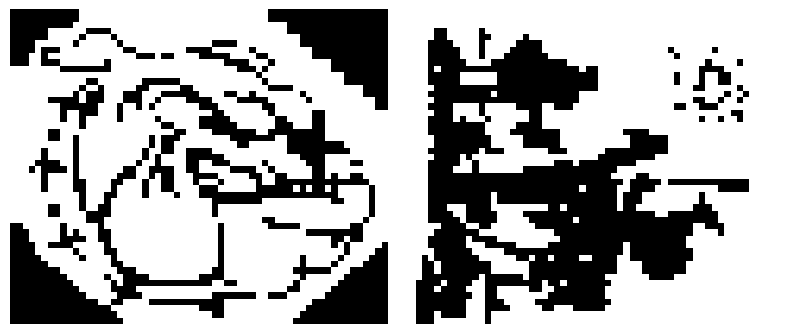

In [17]:
scale = (60,50)
pandaScaled = cv2.resize(pandaOriginal, scale, interpolation=cv2.INTER_NEAREST)
vScaled = cv2.resize(vOriginal, scale, interpolation=cv2.INTER_NEAREST)
perroScaled = cv2.resize(perroOriginal, scale, interpolation=cv2.INTER_NEAREST)
quijoteScaled = cv2.resize(quijoteOriginal, scale, interpolation=cv2.INTER_NEAREST)
palomaScaled = cv2.resize(palomaOriginal, scale, interpolation=cv2.INTER_NEAREST)
toreroScaled = cv2.resize(toreroOriginal, scale, interpolation=cv2.INTER_NEAREST)

show_two_images(perroScaled, quijoteScaled)


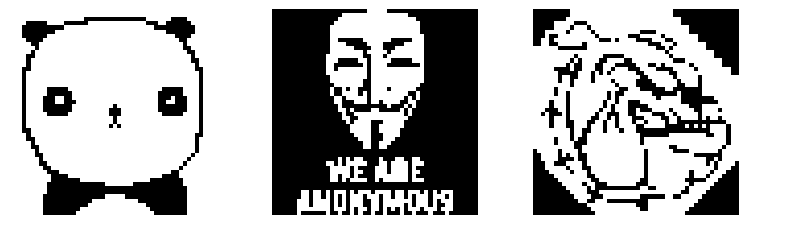

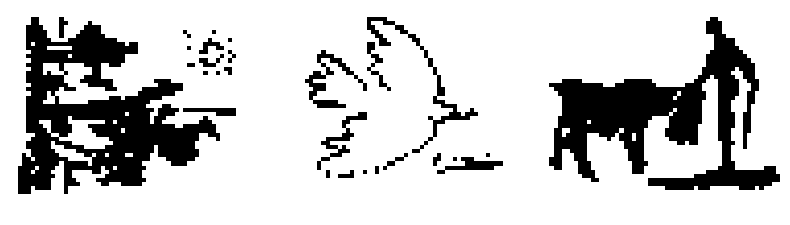

In [18]:
pandaFullfil = np.hstack([pandaOriginal.copy(),np.full((50, 10),255)])
vFullfil = np.hstack([vOriginal.copy(),np.full((50, 10),255)])
perroFullfil = np.hstack([perroOriginal.copy(),np.full((50, 10),255)])
quijoteFullfil = np.vstack([quijoteOriginal.copy(),np.full((5, 60),255)])
palomaFullfil = np.vstack([palomaOriginal.copy(),np.full((5, 60),255)])
toreroFullfil = np.vstack([toreroOriginal.copy(),np.full((5, 60),255)])

show_three_images(pandaFullfil,vFullfil,perroFullfil)
show_three_images(quijoteFullfil,palomaFullfil,toreroFullfil)


Para entrenar a la red neuronal o evaluarla, necesito a las imagenes en forma de vector y en el caso del entrenamiento cada imagen va a ser la columna de una matriz

In [19]:
def load_image_to_pattern(image):
    _, binary_image = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY) # Convertir la imagen binaria a valores 0 y 1
    patron = (binary_image / 255.0) * 2 - 1 # Convertir la imagen binaria a valores -1 y 1
    return patron.flatten() # Me devuelve un arreglo unidimensional

In [20]:
def recover_image(imageVectorized, originalShape = scale):
    # Reconvertir el estado 1D a la forma original de la imagen
    recoveredImage = imageVectorized.reshape(originalShape)
    
    # Convertir de valores -1, 1 a 0, 255 para poder visualizar como imagen
    recoveredImage = (recoveredImage + 1) / 2 * 255
    return recoveredImage.astype(np.uint8)

Creo la clase de la Red Hopfield con todas las funciones para su entrenamiento y evaluacion

In [21]:
def sign_function(input):
    return np.where(input > 0,1,-1)


class HopfieldNetwork:
    def __init__(self, num_neurons):
        self.num_neurons = num_neurons
        self.weights = np.zeros((num_neurons, num_neurons))


    def train(self, patterns):
        self.weights += patterns @ patterns.T
        np.fill_diagonal(self.weights, 0)
    

    def evaluate_asynchronous(self, inicialInput):
        state = inicialInput
        previousState= np.zeros((self.num_neurons, 1))
        cicles = 0
        while not (np.array_equal(state, previousState)):
            previousState = state
            indices = np.random.permutation(self.num_neurons)
            for i in indices :
                sum = np.dot(self.weights[i,:], state)
                state[i] = sign_function(sum)                
            cicles += 1 
        return state,cicles
    
    
    def evaluate_synchronous(self, pattern):
        sum_values = self.weights @ pattern

        return sign_function(sum_values)
    

Voy a probar una red entrenada solo con las imagenes 50x50

In [22]:
patterns1 = []
patterns1.append(load_image_to_pattern(pandaOriginal))
patterns1.append(load_image_to_pattern(vOriginal))
patterns1.append(load_image_to_pattern(perroOriginal))
patterns1 = np.array(patterns1).T

red1 = HopfieldNetwork(2500)
red1.train(patterns1)

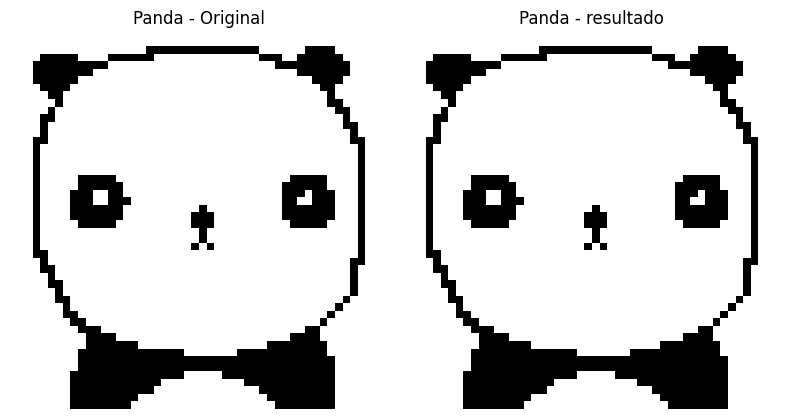

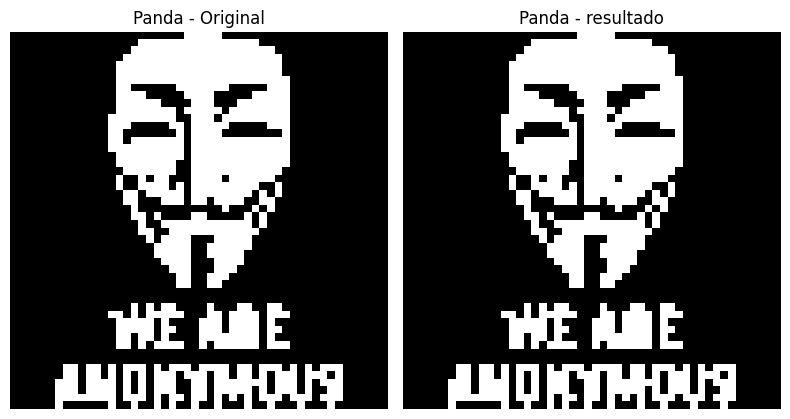

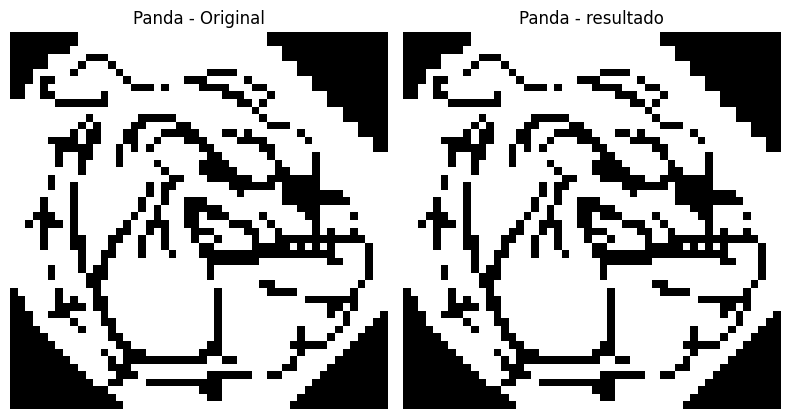

In [23]:
for i in [pandaOriginal, vOriginal, perroOriginal]:
    example,_ = red1.evaluate_asynchronous(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,50))
    show_two_images(i, Recovered, "Panda - Original", "Panda - resultado")

1


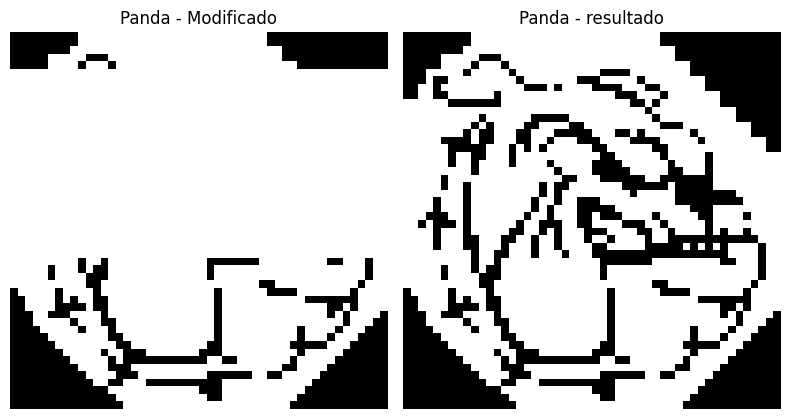

In [24]:
pandaRecortado = perroOriginal.copy()
pandaRecortado[5:30,:] = 255
example,cicles = red1.evaluate_asynchronous(load_image_to_pattern(pandaRecortado))
Recovered = recover_image(example, (50,50))
print(cicles)
show_two_images(pandaRecortado, Recovered, "Panda - Modificado", "Panda - resultado")

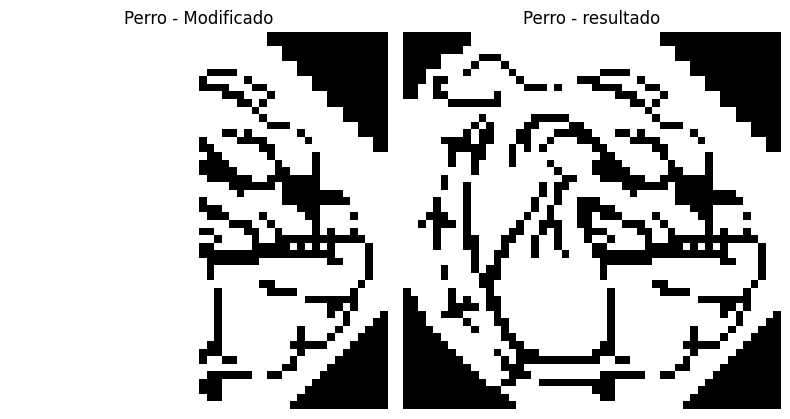

In [25]:
perroRecortado = perroOriginal.copy()
perroRecortado[:,0:25] = 255
example,_ = red1.evaluate_asynchronous(load_image_to_pattern(perroRecortado))
Recovered = recover_image(example, (50,50))
show_two_images(perroRecortado, Recovered, "Perro - Modificado", "Perro - resultado")


Pruebo red neuronal para el caso de completar los pixeles faltantes de las imagenes

In [26]:
pandaFullfil = np.hstack([pandaOriginal.copy(),np.zeros((50, 10))])
vFullfil = np.hstack([vOriginal.copy(),np.zeros((50, 10))])
perroFullfil = np.hstack([perroOriginal.copy(),np.zeros((50, 10))])
quijoteFullfil = np.vstack([quijoteOriginal.copy(),np.zeros((5, 60))])
palomaFullfil = np.vstack([palomaOriginal.copy(),np.zeros((5, 60))])
toreroFullfil = np.vstack([toreroOriginal.copy(),np.zeros((5, 60))])

In [27]:

patterns2 = []
patterns2.append(load_image_to_pattern(pandaFullfil))
patterns2.append(load_image_to_pattern(vFullfil))
patterns2.append(load_image_to_pattern(perroFullfil))
patterns2.append(load_image_to_pattern(palomaFullfil))
patterns2.append(load_image_to_pattern(toreroFullfil))
patterns2.append(load_image_to_pattern(quijoteFullfil))
patterns2 = np.array(patterns2).T

red2 = HopfieldNetwork(3000)
red2.train(patterns2)


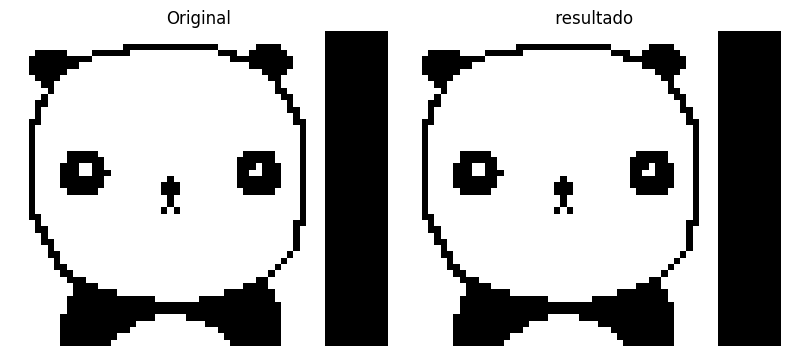

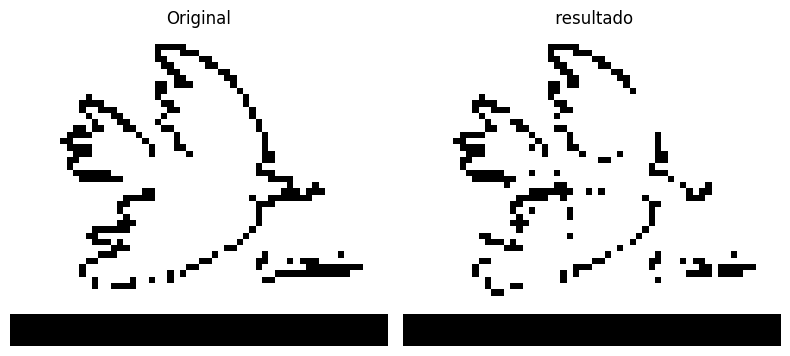

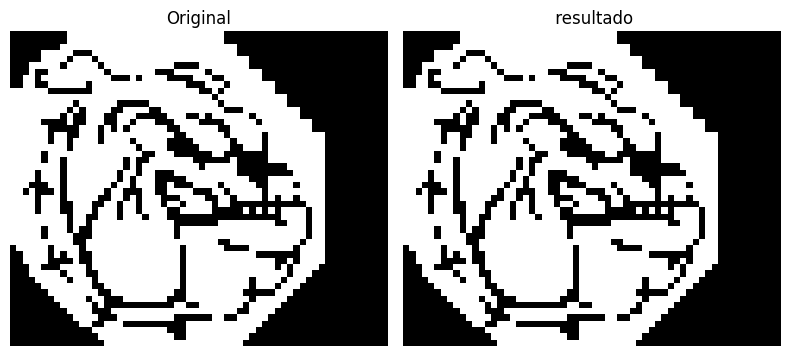

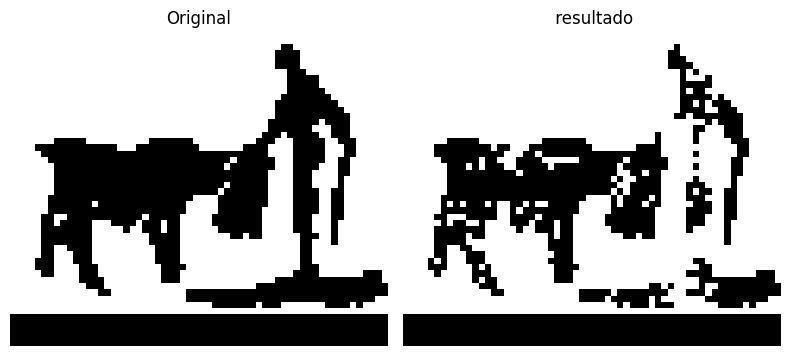

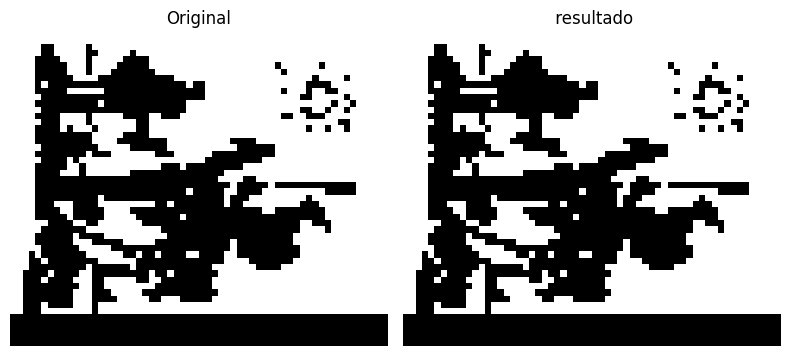

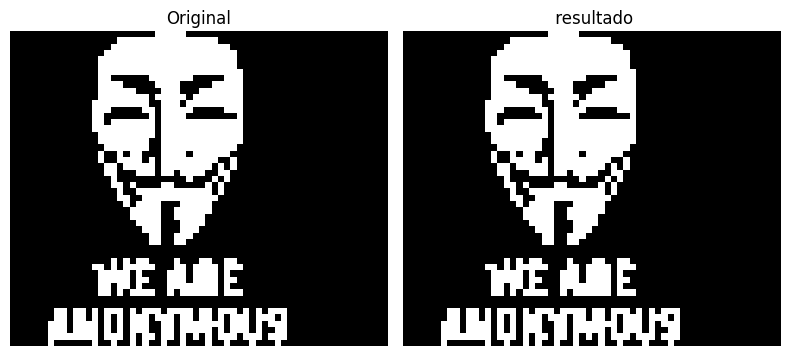

In [28]:
for i in [pandaFullfil, palomaFullfil, perroFullfil, toreroFullfil, quijoteFullfil, vFullfil]:
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,60))
    show_two_images(i, Recovered, "Original", " resultado")

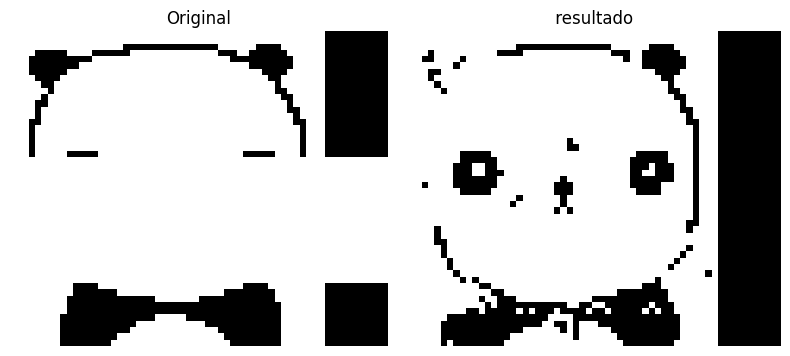

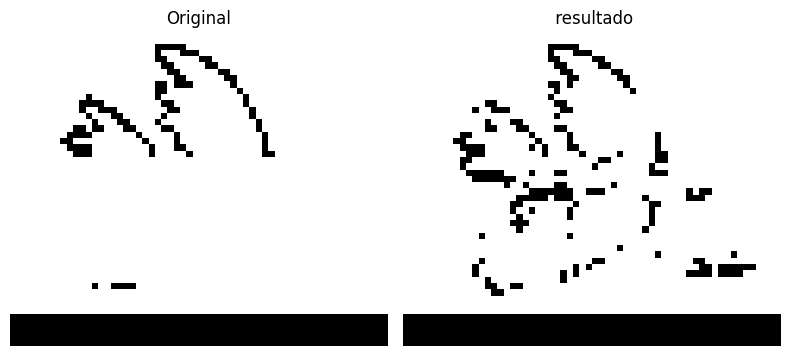

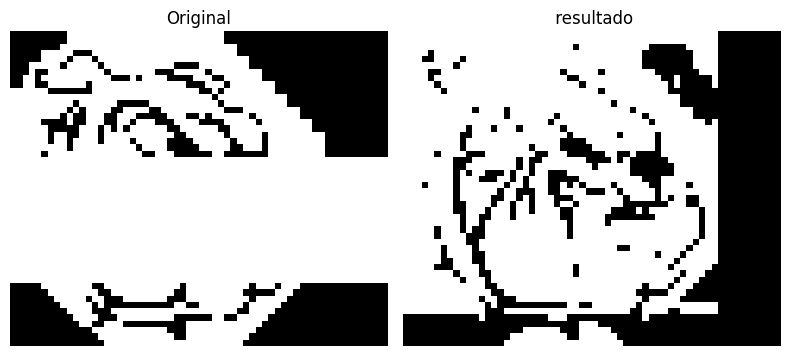

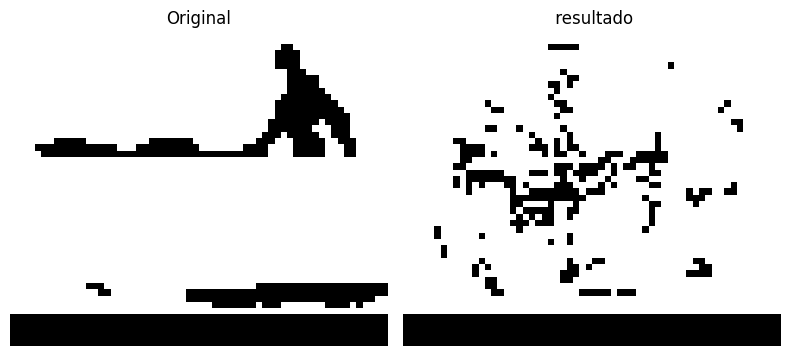

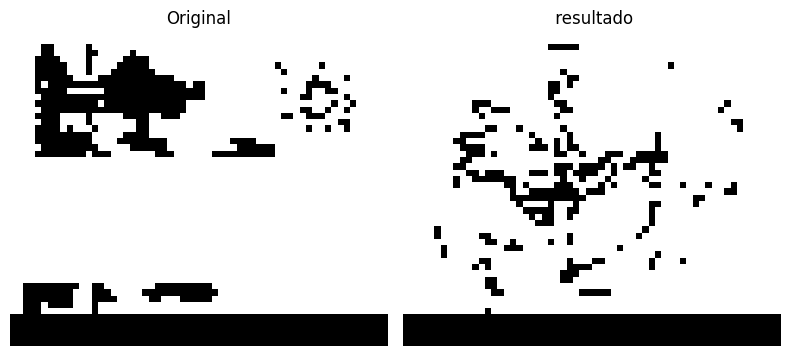

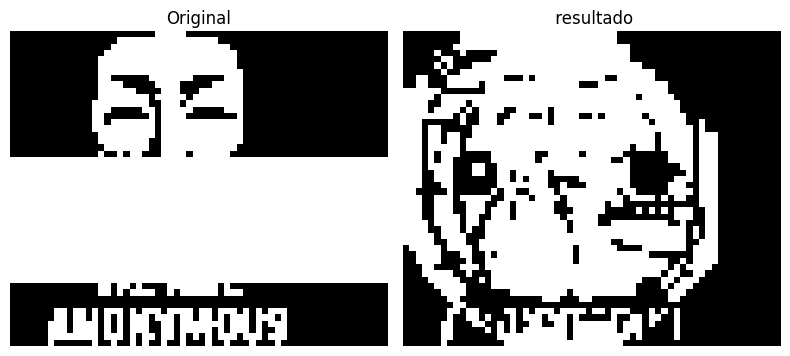

In [29]:
for i in [pandaFullfil, palomaFullfil, perroFullfil, toreroFullfil, quijoteFullfil, vFullfil]:
    aux = i.copy()
    aux[20:40, :] = 255
    example,_ = red2.evaluate_asynchronous(load_image_to_pattern(aux))
    Recovered = recover_image(example, (50,60))
    show_two_images(aux, Recovered, "Original", " resultado")

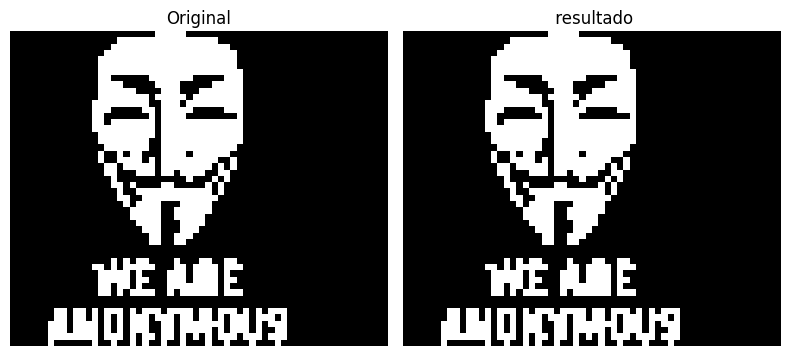

In [30]:
example,_ = red2.evaluate_asynchronous(load_image_to_pattern(vFullfil))
Recovered = recover_image(example, (50,60))
show_two_images(vFullfil, Recovered, "Original", " resultado")

Ahora pruebo una red neuronal con imagenes escaladas

In [31]:
patterns3 = []
patterns3.append(load_image_to_pattern(pandaScaled))
patterns3.append(load_image_to_pattern(vScaled))
patterns3.append(load_image_to_pattern(perroScaled))
patterns3.append(load_image_to_pattern(palomaScaled))
patterns3.append(load_image_to_pattern(toreroScaled))
patterns3.append(load_image_to_pattern(quijoteScaled))
patterns3 = np.array(patterns3).T

red3 = HopfieldNetwork(3000)
red3.train(patterns3)

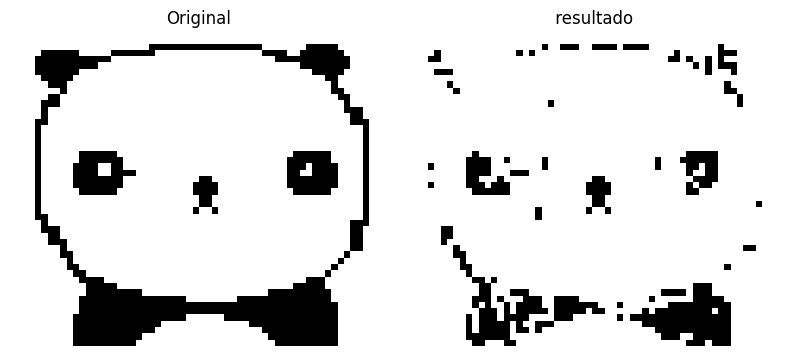

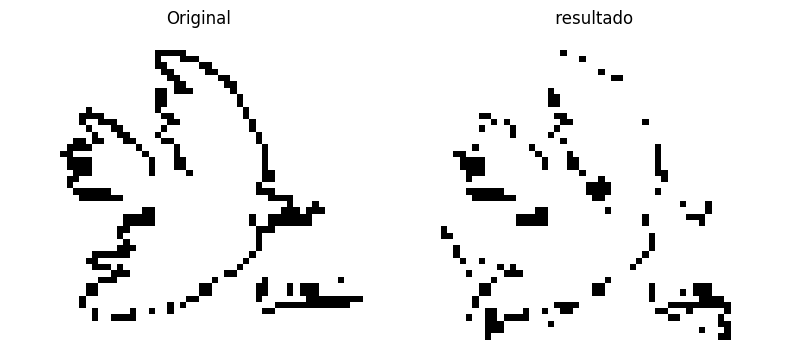

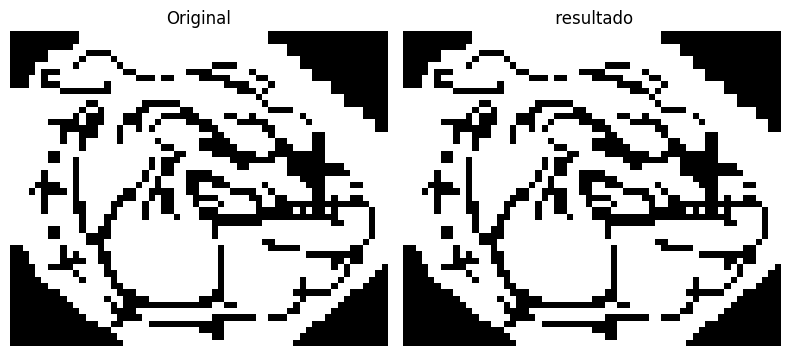

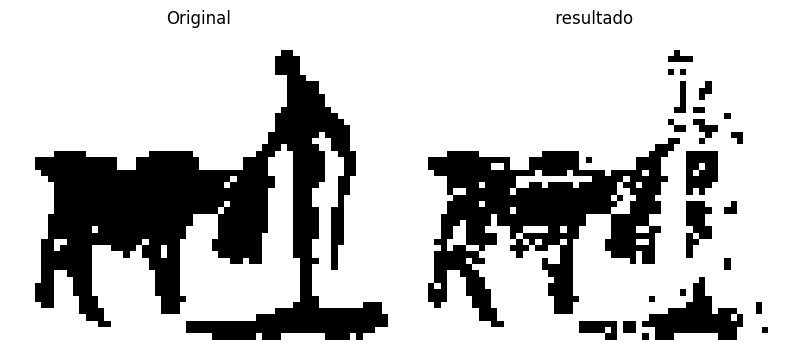

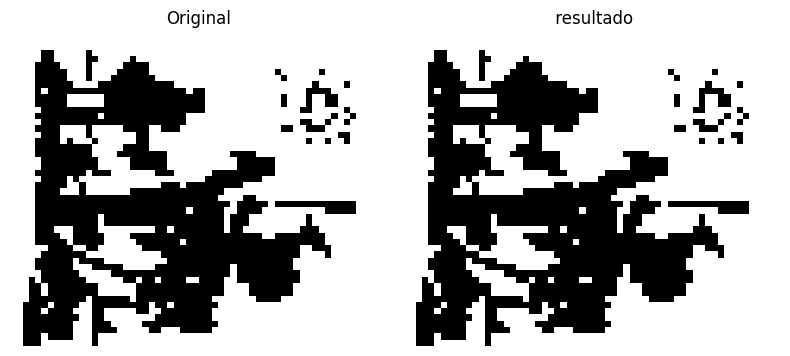

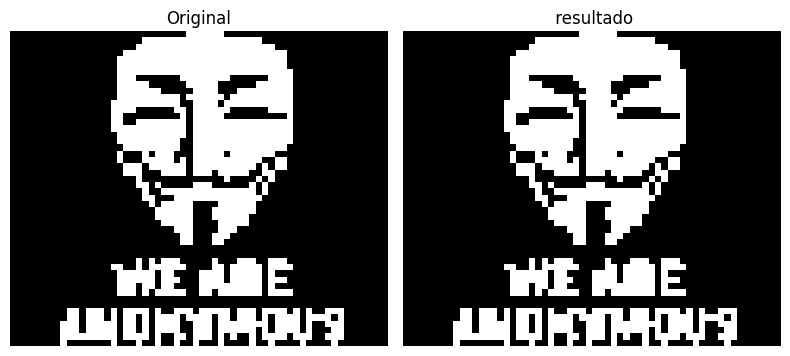

In [32]:
for i in [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]:
    example,_ = red3.evaluate_asynchronous(load_image_to_pattern(i))
    Recovered = recover_image(example, (50,60))
    show_two_images(i, Recovered, "Original", " resultado")

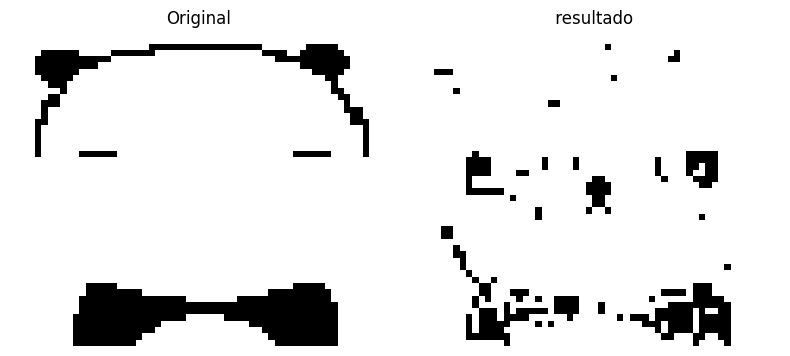

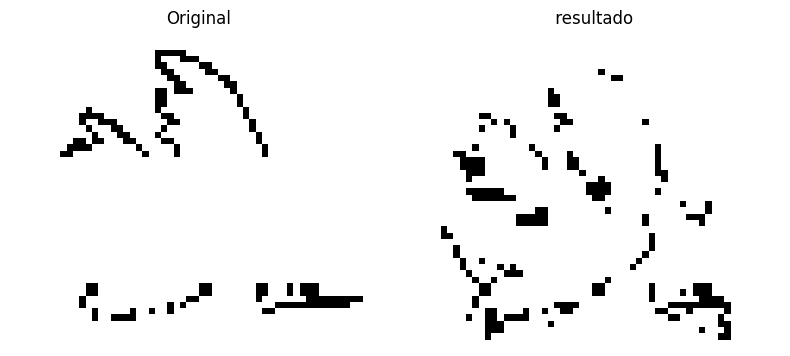

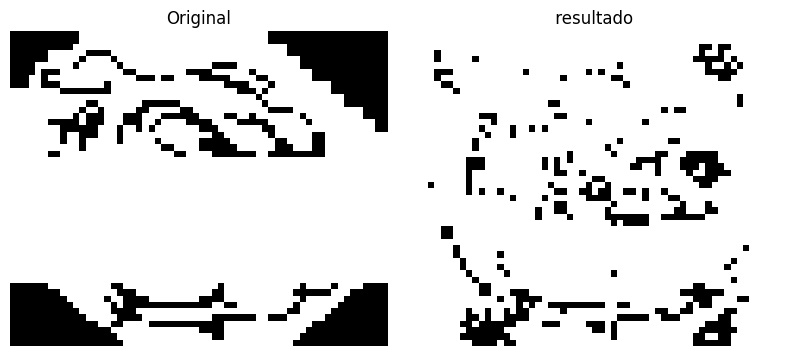

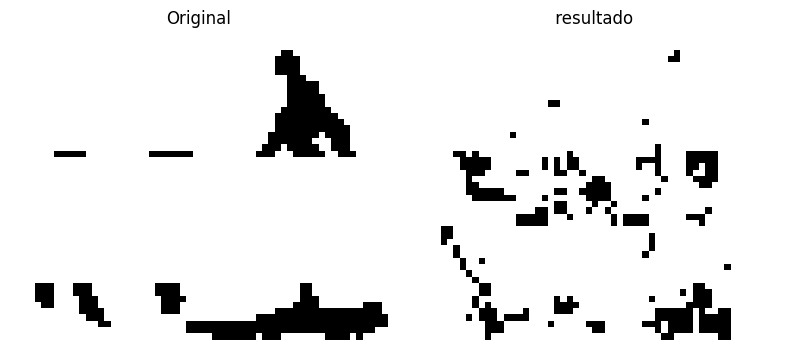

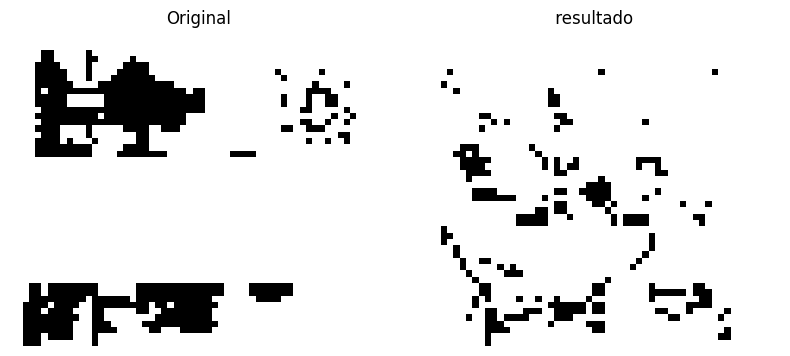

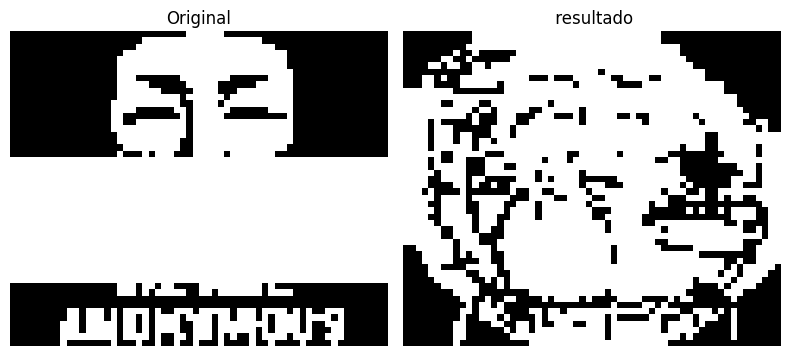

In [33]:
for i in [pandaScaled, palomaScaled, perroScaled, toreroScaled, quijoteScaled, vScaled]:
    aux = i.copy()
    aux[20:40, :] = 255
    example,_ = red3.evaluate_asynchronous(load_image_to_pattern(aux))
    Recovered = recover_image(example, (50,60))
    show_two_images(aux, Recovered, "Original", " resultado")

EJERCICIO 2

In [34]:
def generate_random_pattern(num_neurons):
    # Generar un solo patrón aleatorio (-1 o 1)
    return np.random.choice([-1, 1], size=(num_neurons,))


def capacity_by_error(P_error, N):
    hopfield_net = HopfieldNetwork(N)
    patterns_accumulated = np.empty((N, 0)) 
    error_neurons = 0
    
    while error_neurons < P_error:
        new_pattern = generate_random_pattern(N).reshape(N, 1)  # Genera una columna
        hopfield_net.train(new_pattern)  # Entrenamos con el patrón como vector unidimensional
        
        patterns_accumulated = np.hstack((patterns_accumulated, new_pattern))
        
        evaluated_patterns = hopfield_net.evaluate_synchronous(patterns_accumulated)
        
        differences = evaluated_patterns- patterns_accumulated
        error_neurons = np.count_nonzero(differences) / (patterns_accumulated.shape[1]*N)
    capacity = (patterns_accumulated.shape[1]-1)/N
    return capacity



In [35]:
capacities = []
aux = 0
for i in [0.0010,0.0036,0.0100,0.0500,0.1000]:
    capacities.append(capacity_by_error(i, 1000))
    print(f"Perror = {i}      Pmax/N ={capacities[aux]}\n")
    aux = aux + 1


Perror = 0.001      Pmax/N =0.103

Perror = 0.0036      Pmax/N =0.138

Perror = 0.01      Pmax/N =0.186

Perror = 0.05      Pmax/N =0.371

Perror = 0.1      Pmax/N =0.61



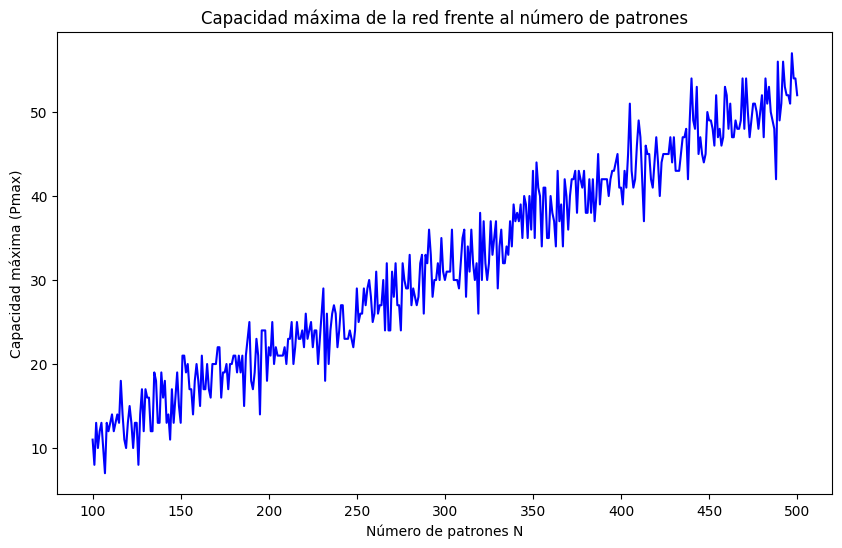

In [36]:
N = 500
Perror= 0.001
Pmax = []
for i in range(100,N+1):
    Pmax.append(capacity_by_error(Perror, i)*i)

x = np.arange(100, N + 1)
# Crear la gráfica
plt.figure(figsize=(10, 6))  # Tamaño de la figura (opcional)
plt.plot(x, Pmax, linestyle='-', color='b')  # Línea con marcadores
plt.xlabel('Número de patrones N')
plt.ylabel('Capacidad máxima (Pmax)')
plt.title('Capacidad máxima de la red frente al número de patrones')
plt.show()

Calculando para correlación: 0.0
Iteración: 1, Error: 0.00000
Iteración: 2, Error: 0.00000
Iteración: 3, Error: 0.00000
Iteración: 4, Error: 0.00000
Iteración: 5, Error: 0.00000
Iteración: 6, Error: 0.00000
Iteración: 7, Error: 0.00000
Iteración: 8, Error: 0.00000
Iteración: 9, Error: 0.00000
Iteración: 10, Error: 0.00000
Iteración: 11, Error: 0.00000
Iteración: 12, Error: 0.00000
Iteración: 13, Error: 0.00000
Iteración: 14, Error: 0.00000
Iteración: 15, Error: 0.00000
Iteración: 16, Error: 0.00000
Iteración: 17, Error: 0.00000
Iteración: 18, Error: 0.00000
Iteración: 19, Error: 0.00000
Iteración: 20, Error: 0.00000
Iteración: 21, Error: 0.00000
Iteración: 22, Error: 0.00000
Iteración: 23, Error: 0.00000
Iteración: 24, Error: 0.00000
Iteración: 25, Error: 0.00000
Iteración: 26, Error: 0.00000
Iteración: 27, Error: 0.00000
Iteración: 28, Error: 0.00000
Iteración: 29, Error: 0.00000
Iteración: 30, Error: 0.00000
Iteración: 31, Error: 0.00000
Iteración: 32, Error: 0.00000
Iteración: 33, E

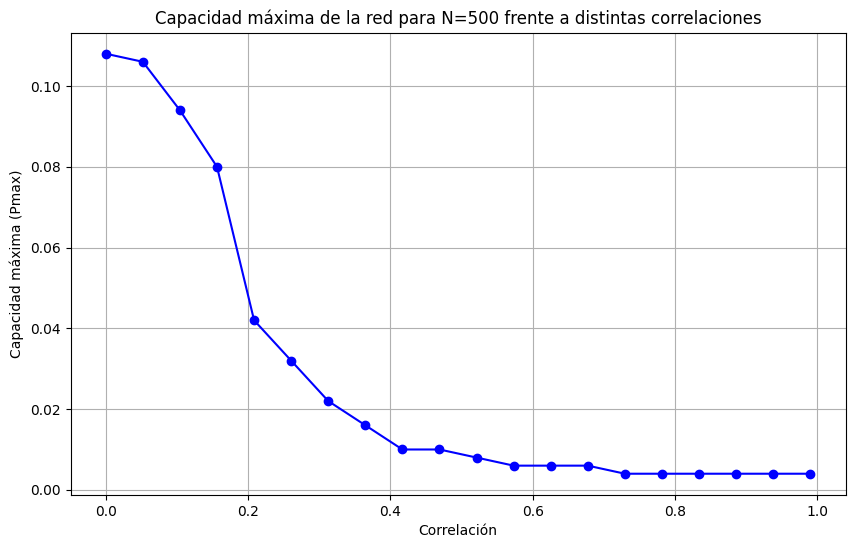

In [104]:
def generate_correlated_patterns_bernoulli(base_pattern, correlation, num_patterns):
    """
    Genera patrones correlacionados utilizando una distribución Bernoulli controlada por un vector de arranque.
    
    Parameters:
    - base_pattern: Patrón base a partir del cual generar los nuevos patrones.
    - correlation: Grado de correlación deseada (entre 0 y 1).
    - num_patterns: Número de patrones correlacionados a generar.
    
    Returns:
    - correlated_patterns: Matriz con los patrones correlacionados.
    """
    N = len(base_pattern)
    correlated_patterns = np.empty((N, num_patterns))
    
    for i in range(num_patterns):
        for j in range(N):
            prob = (1 + correlation) / 2 if base_pattern[j] == 1 else (1 - correlation) / 2
            correlated_patterns[j, i] = 1 if np.random.rand() < prob else -1
    
    return correlated_patterns

def capacity_by_error_correlated(P_error, N, correlation, max_iter=1000):
    """
    Calcula la capacidad máxima de la red de Hopfield para patrones correlacionados.
    
    Parameters:
    - P_error: Error máximo permitido.
    - N: Número de neuronas.
    - correlation: Correlación entre los patrones.
    - max_iter: Número máximo de iteraciones permitidas.
    
    Returns:
    - Capacidad máxima estimada.
    """
    hopfield_net = HopfieldNetwork(N)
    patterns_accumulated = np.empty((N, 0))
    error_neurons = 0
    iteration = 0
    
    # Generar patrón base aleatorio
    base_pattern = generate_random_pattern(N)
    
    while error_neurons < P_error and iteration < max_iter:
        # Generamos un nuevo patrón correlacionado con la distribución Bernoulli
        correlated_pattern = generate_correlated_patterns_bernoulli(base_pattern, correlation, 1).reshape(N, 1)
        
        hopfield_net.train(correlated_pattern)
        patterns_accumulated = np.hstack((patterns_accumulated, correlated_pattern))
        
        evaluated_patterns = hopfield_net.evaluate_synchronous(patterns_accumulated)
        
        differences = evaluated_patterns - patterns_accumulated
        error_neurons = np.count_nonzero(differences) / (patterns_accumulated.shape[1] * N)
        
        iteration += 1
       
        print(f"Iteración: {iteration}, Error: {error_neurons:.5f}")
    capacity = (patterns_accumulated.shape[1] - 1) / N
    return capacity

def plot_capacity_by_correlation(N, P_error, correlations, max_iter=1000):
    """
    Genera un gráfico de la capacidad máxima de la red (Pmax) para distintas correlaciones
    y un número fijo de neuronas N.
    
    Parameters:
    - N: Número de neuronas (constante).
    - P_error: Error máximo permitido para evaluar Pmax.
    - correlations: Lista de valores de correlación a probar.
    - max_iter: Número máximo de iteraciones permitidas en el entrenamiento.
    """
    Pmax_values = []

    for corr in correlations:
        print(f"Calculando para correlación: {corr}")

        capacities = capacity_by_error_correlated(P_error, N, corr, max_iter)
        Pmax_values.append(capacities)

    # Graficar Pmax en función de las correlaciones
    plt.figure(figsize=(10, 6))
    plt.plot(correlations, Pmax_values, marker='o', linestyle='-', color='b')
    plt.xlabel('Correlación')
    plt.ylabel('Capacidad máxima (Pmax)')
    plt.title(f'Capacidad máxima de la red para N={N} frente a distintas correlaciones')
    plt.grid(True)
    plt.show()

# Parámetros
N = 500
P_error = 0.001
correlations = np.linspace(0, 0.99, 20)  # Correlaciones desde 0 hasta 1 (0, 0.1, 0.2, ..., 1)

# Llamar a la función de graficado
plot_capacity_by_correlation(N, P_error, correlations, max_iter=200)